In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline

df = pd.read_csv("retail_store_inventory.csv")
print(df.shape)
print(df.columns.tolist())

(73100, 15)
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']


In [13]:
for col in df.columns:
    print(col)

Date
Store ID
Product ID
Category
Region
Inventory Level
Units Sold
Units Ordered
Demand Forecast
Price
Discount
Weather Condition
Holiday/Promotion
Competitor Pricing
Seasonality


In [15]:
print(df.isnull().sum())

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


In [16]:
print(df.duplicated().sum())

0


In [17]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst = True)
print(df["Date"].dtype)

datetime64[ns]


In [18]:
print(df["Date"].min(), df["Date"].max())

2022-01-01 00:00:00 2024-01-01 00:00:00


In [19]:
daily_totals = df.groupby(["Category", "Date"])["Units Sold"].sum()
category_group = daily_totals.groupby("Category")
annual_demand = df.groupby("Category")["Units Sold"].sum() / 2
avg_daily_demand = category_group.mean()                          
max_daily_demand = category_group.max()

print(annual_demand)
print(avg_daily_demand)
print(max_daily_demand)

Category
Clothing        999583.0
Electronics     980216.0
Furniture      1012508.5
Groceries      1000241.0
Toys            995242.5
Name: Units Sold, dtype: float64
Category
Clothing       2734.837209
Electronics    2681.849521
Furniture      2770.201094
Groceries      2736.637483
Toys           2722.961696
Name: Units Sold, dtype: float64
Category
Clothing       5227
Electronics    5053
Furniture      5551
Groceries      5465
Toys           5340
Name: Units Sold, dtype: int64


In [20]:
ordering_cost = 50
holding_cost_rate = 0.2
df["holding_cost"] = (df["Price"] * holding_cost_rate)
grouped = df.groupby("Category")
avg_holding_cost = grouped["holding_cost"].mean()

print(avg_holding_cost)

Category
Clothing       10.977320
Electronics    11.062153
Furniture      11.035172
Groceries      11.054244
Toys           11.006482
Name: holding_cost, dtype: float64


In [21]:
lead_time = 7
grouped = df.groupby("Category")
Safety_stock = (max_daily_demand - avg_daily_demand) * lead_time
print(Safety_stock)

Category
Clothing       17445.139535
Electronics    16598.053352
Furniture      19465.592339
Groceries      19098.537620
Toys           18319.268126
Name: Units Sold, dtype: float64


In [23]:
grouped = df.groupby("Category")
Reorder_point = ( avg_daily_demand * lead_time ) + Safety_stock
print(Reorder_point)

Category
Clothing       36589.0
Electronics    35371.0
Furniture      38857.0
Groceries      38255.0
Toys           37380.0
Name: Units Sold, dtype: float64


In [24]:
df["forecast_error"] = df["Units Sold"] - df["Demand Forecast"]
avg_forecast_error = df.groupby("Category")["forecast_error"].mean()
print(avg_forecast_error)

Category
Clothing      -5.064314
Electronics   -4.994777
Furniture     -5.058610
Groceries     -4.950691
Toys          -5.080324
Name: forecast_error, dtype: float64


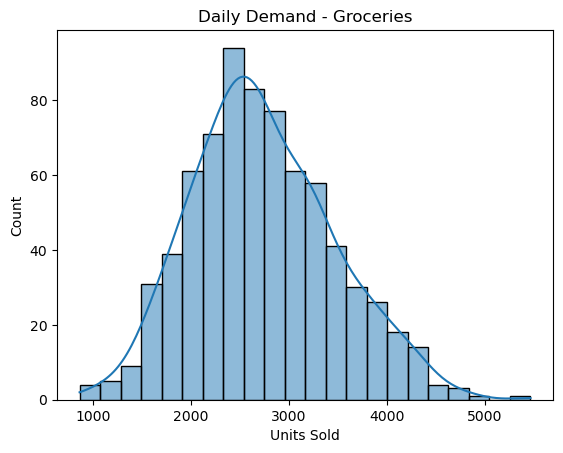

Groceries : 0.0001382778220438961


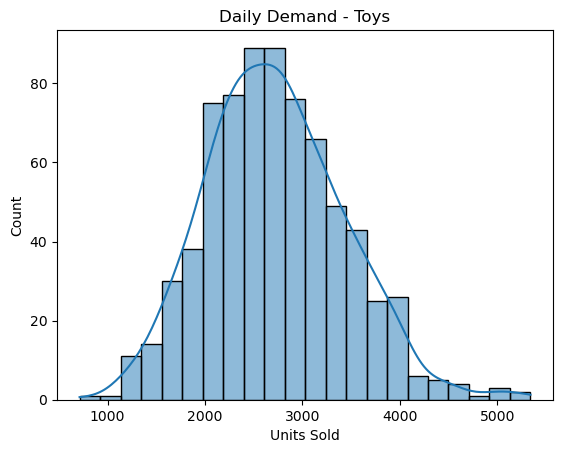

Toys : 0.00013568551992892126


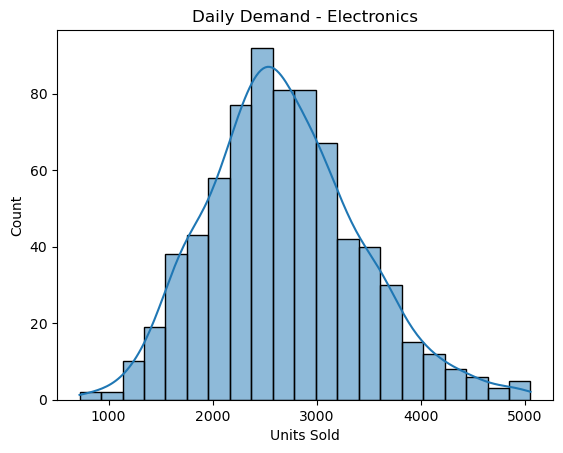

Electronics : 3.756333656340918e-05


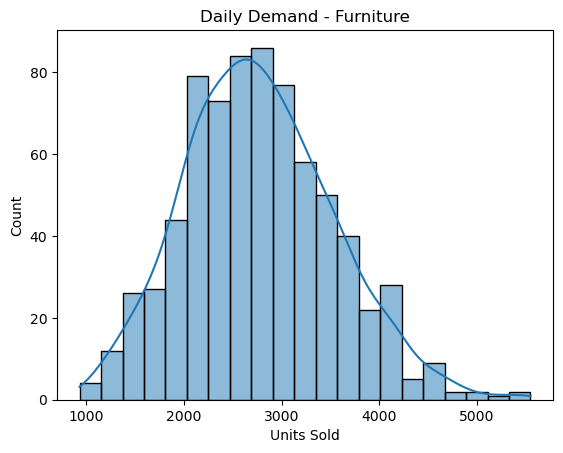

Furniture : 0.0003168969865251949


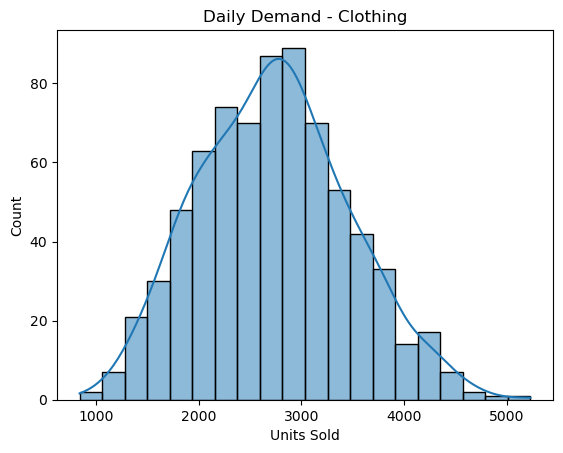

Clothing : 0.015008936444113672


In [27]:
categories = df["Category"].unique()

for cat in categories:
    demand = daily_totals[cat]
    
    sns.histplot(demand, kde=True)
    plt.title(f"Daily Demand - {cat}")
    plt.show()
    
    stat, p_value = stats.shapiro(demand)
    print(cat, ":", p_value)

In [29]:
category_group = daily_totals.groupby("Category")
demand_std = category_group.std()
print(demand_std)



Category
Clothing       729.970082
Electronics    725.128931
Furniture      758.666813
Groceries      726.571215
Toys           709.291693
Name: Units Sold, dtype: float64


In [30]:
service_level = 0.95
z_score = stats.norm.ppf(service_level)
print(z_score)

1.6448536269514722


In [33]:
new_safety_stock = z_score * demand_std * np.sqrt(lead_time)
print(new_safety_stock)

Category
Clothing       3176.737556
Electronics    3155.669480
Furniture      3301.622106
Groceries      3161.946117
Toys           3086.747821
Name: Units Sold, dtype: float64


In [34]:
new_reorder_point = (avg_daily_demand * lead_time) + new_safety_stock
print(new_reorder_point)

Category
Clothing       22320.598021
Electronics    21928.616128
Furniture      22693.029767
Groceries      22318.408497
Toys           22147.479695
Name: Units Sold, dtype: float64


In [35]:
comparison = pd.DataFrame({
    "Old Safety Stock": Safety_stock,
    "New Safety Stock": new_safety_stock,
    "Old ROP": Reorder_point,
    "New ROP": new_reorder_point
})
print(comparison)

             Old Safety Stock  New Safety Stock  Old ROP       New ROP
Category                                                              
Clothing         17445.139535       3176.737556  36589.0  22320.598021
Electronics      16598.053352       3155.669480  35371.0  21928.616128
Furniture        19465.592339       3301.622106  38857.0  22693.029767
Groceries        19098.537620       3161.946117  38255.0  22318.408497
Toys             18319.268126       3086.747821  37380.0  22147.479695


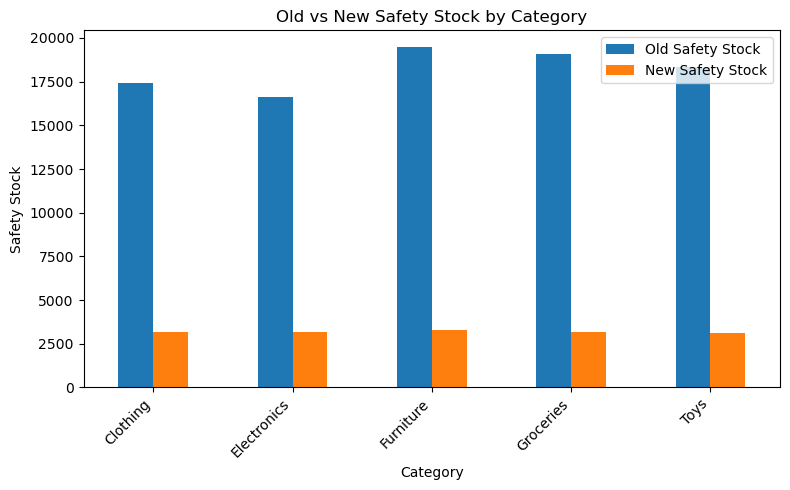

In [40]:
comparison[["Old Safety Stock", "New Safety Stock"]].plot(kind="bar", figsize=(8,5))
plt.title("Old vs New Safety Stock by Category")
plt.ylabel("Safety Stock")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()

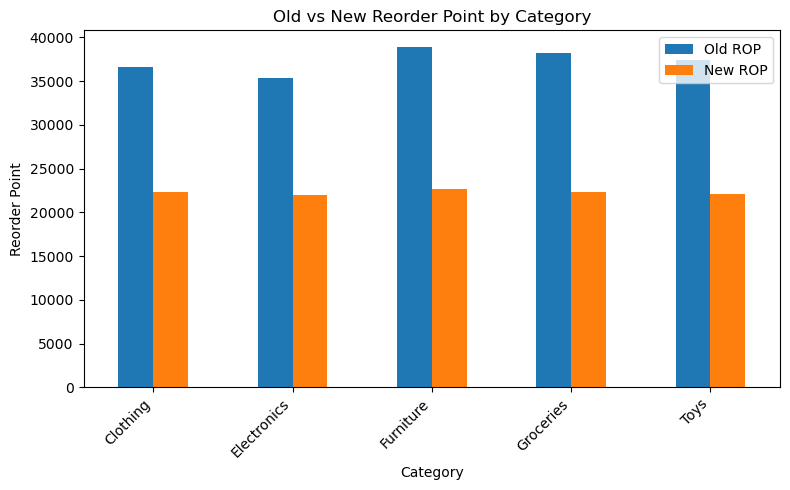

In [41]:
comparison[["Old ROP", "New ROP"]].plot(kind="bar", figsize=(8,5))
plt.title("Old vs New Reorder Point by Category")
plt.ylabel("Reorder Point")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()


In [45]:
print(df["Discount"].unique())

[20 10  0  5 15]


In [42]:
corr, p_value = stats.pearsonr(df["Discount"], df["Units Sold"])
print(corr, p_value)

0.0025756510203160956 0.48619820137145814


In [43]:
print(df["Holiday/Promotion"].unique())

[0 1]


In [44]:
corr, p_value = stats.pearsonr(df["Holiday/Promotion"], df["Units Sold"])
print(corr, p_value)

-0.0003738886703609552 0.9194817165094379


In [46]:
print(df["Weather Condition"].unique())

['Rainy' 'Sunny' 'Cloudy' 'Snowy']


In [48]:
weather_demand = df.groupby("Weather Condition")["Units Sold"].mean()
print(weather_demand)

Weather Condition
Cloudy    136.758324
Rainy     135.160028
Snowy     135.911559
Sunny     138.028650
Name: Units Sold, dtype: float64


## Findings — Part 2: Demand Forecasting & Statistical Safety Stock

**Forecast Accuracy**
The dataset's built-in demand forecast slightly over-predicted actual sales across
every category, with an average error of about -5 units per row (Units Sold minus
Demand Forecast). This bias was remarkably consistent across all five categories
(-4.95 to -5.08), suggesting either a uniform forecasting method or, more likely,
that the dataset's demand values were synthetically generated.

**Demand Distribution**
A Shapiro-Wilk normality test was run on daily demand for each category. All five
categories returned p-values below 0.05, meaning none technically qualify as a
perfect normal distribution. However, the histograms visually resembled a bell
curve, and using demand variability (standard deviation) with a Z-score-based
Safety Stock formula remains a standard, widely accepted simplification in real-world
supply chain practice — so the analysis proceeded on that basis, with this
limitation noted.

**Old vs New Safety Stock & Reorder Point**
This is the core result of Part 2. Replacing the Part 1 heuristic
(`(max − avg) × lead_time`) with a proper statistical formula
(`Z × std_dev × sqrt(lead_time)`, at a 95% service level) reduced Safety Stock by
roughly 5–6x across every category — for example, Clothing's Safety Stock dropped
from ~17,445 units to ~3,177 units. Reorder Point dropped by roughly 35–40% as a
result. This shows that Part 1's simple max-min heuristic was substantially
over-buffering inventory across the board, since it was driven by a single extreme
demand day rather than typical day-to-day variability.

**Demand Drivers**
Discount level, Holiday/Promotion status, and Weather Condition were each checked
against Units Sold. None showed a meaningful relationship — Discount and
Holiday/Promotion had correlation values near zero with high p-values (not
statistically significant), and average demand across weather types varied by only
~2 units. This reinforces the earlier observation that demand in this dataset
appears largely uniform and possibly synthetic, rather than reflecting real-world
retail patterns where these factors typically matter.

### Limitations
- Daily demand does not pass a strict normality test, even though the Z-score
  method assumes approximate normality.
- The 95% service level was a chosen assumption, not derived from business
  constraints or cost tradeoffs.
- The dataset shows patterns (uniform demand across categories, no effect from
  discounts/promotions/weather) consistent with synthetic rather than real-world data.